# HR Analytics AI System
## Notebook 6: Employee Segmentation using K-Means Clustering

Clustering is an unsupervised machine learning technique that groups
similar employees together based on their characteristics.

In this notebook, we will:

1. Prepare and scale features for clustering
2. Determine the optimal number of clusters using the Elbow Method
3. Train a K-Means clustering model
4. Evaluate the clusters using the Silhouette Score
5. Analyze and interpret each employee segment

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Initialize Spark Session and Load Data

We initialize the Spark Session and load the engineered dataset
from the Parquet file saved in Notebook 4.


In [17]:
spark = SparkSession.builder \
    .appName("HR Analytics - Clustering") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data_engineered.parquet"
)

print("Data Loaded Successfully.")
print(f"Total Rows: {df.count()}")
print(f"Total Columns: {len(df.columns)}")

Data Loaded Successfully.
Total Rows: 1470
Total Columns: 36


### 2. Prepare Features for Clustering

We select the most relevant features for clustering that represent
different aspects of an employee's profile:

- **Compensation:** MonthlyIncome, DailyRate, PercentSalaryHike
- **Experience:** TotalWorkingYears, YearsAtCompany, JobLevel
- **Satisfaction:** EngagementScore, SatisfactionScore
- **Risk:** RiskScore, OverTime_encoded

We then apply StandardScaler to normalize all features to the same scale,
which is essential for K-Means clustering to work correctly.

In [22]:
cluster_features = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "RiskScore"
]

assembler = VectorAssembler(
    inputCols=cluster_features,
    outputCol="features_raw"
)

df_assembled = assembler.transform(df)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=True
)

df_scaled = scaler.fit(df_assembled).transform(df_assembled)

print("Features prepared and scaled successfully.")
print(f"Number of Clustering Features: {len(cluster_features)}")
print("-" * 40)
for i, col in enumerate(cluster_features, 1):
    print(f"{i:2}. {col}")

Features prepared and scaled successfully.
Number of Clustering Features: 6
----------------------------------------
 1. Age
 2. MonthlyIncome
 3. JobLevel
 4. TotalWorkingYears
 5. YearsAtCompany
 6. RiskScore


### 3. Determine Optimal Number of Clusters (Elbow Method)

The Elbow Method helps us find the optimal number of clusters by plotting
the Within Set Sum of Squared Errors (WSSSE) for different values of K.

The optimal K is where the curve starts to flatten, forming an elbow shape.
We test values of K from 2 to 10.

K = 2 → WSSSE = 5151.80
K = 3 → WSSSE = 4070.06
K = 4 → WSSSE = 3530.33
K = 5 → WSSSE = 3137.99
K = 6 → WSSSE = 2895.40
K = 7 → WSSSE = 2554.63
K = 8 → WSSSE = 2312.47
K = 9 → WSSSE = 2186.87
K = 10 → WSSSE = 2125.62


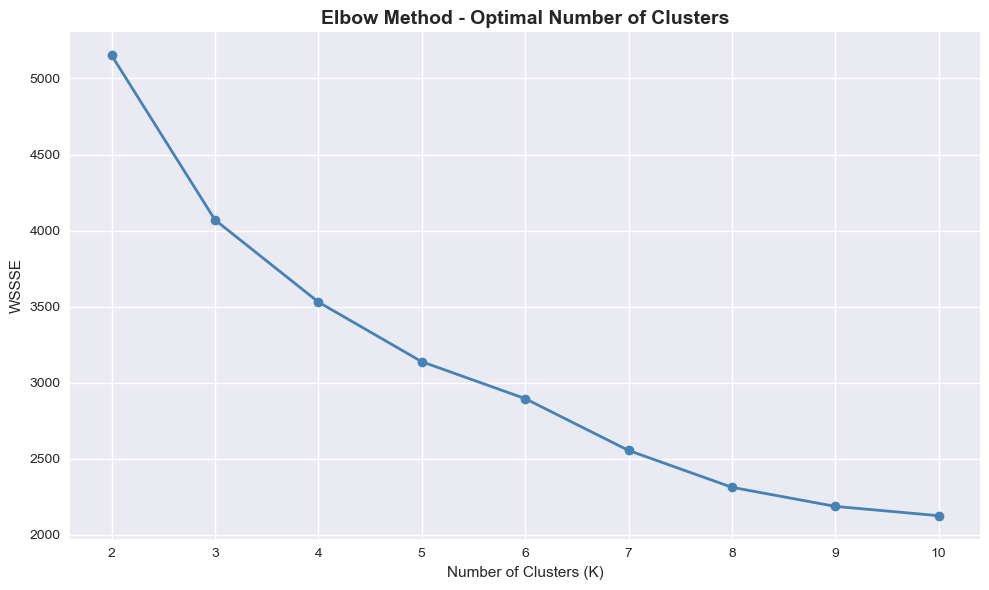

In [23]:
wssse_list = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        featuresCol="features_scaled",
        predictionCol="cluster",
        k=k,
        seed=42
    )
    model = kmeans.fit(df_scaled)
    wssse = model.summary.trainingCost
    wssse_list.append(wssse)
    print(f"K = {k} → WSSSE = {wssse:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, wssse_list, marker='o', color="steelblue", linewidth=2)
plt.title("Elbow Method - Optimal Number of Clusters", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WSSSE")
plt.xticks(k_values)
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\elbow_method.png", dpi=150)
plt.show()

### Elbow Method Results

The Elbow Method plot shows the following WSSSE values:

- K=2 → K=3: WSSSE decreased by 1,081 points
- K=3 → K=4: WSSSE decreased by 540 points
- K=4 → K=5: WSSSE decreased by 392 points
- K=5 → K=6: WSSSE decreased by 242 points

The curve starts to flatten after K=4 and K=5.
We will test both values and select the one with the highest Silhouette Score.

In [24]:
for k in [3, 4, 5]:
    kmeans_test = KMeans(
        featuresCol="features_scaled",
        predictionCol="cluster",
        k=k,
        seed=42
    )
    model_test = kmeans_test.fit(df_scaled)
    df_test = model_test.transform(df_scaled)
    
    evaluator_test = ClusteringEvaluator(
        featuresCol="features_scaled",
        predictionCol="cluster",
        metricName="silhouette"
    )
    score = evaluator_test.evaluate(df_test)
    print(f"K = {k} → Silhouette Score = {score:.4f}")

K = 3 → Silhouette Score = 0.4052
K = 4 → Silhouette Score = 0.3771
K = 5 → Silhouette Score = 0.3947


### 4. Train Final K-Means Model with K = 3

Based on both the Elbow Method and Silhouette Score analysis,
K = 3 is selected as the optimal number of clusters,
achieving the highest Silhouette Score of 0.4052.

In [25]:
kmeans_final = KMeans(
    featuresCol="features_scaled",
    predictionCol="cluster",
    k=3,
    seed=42
)

kmeans_model_final = kmeans_final.fit(df_scaled)
df_clustered = kmeans_model_final.transform(df_scaled)

evaluator_final = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette_final = evaluator_final.evaluate(df_clustered)

print("Final K-Means Model trained successfully.")
print("=" * 40)
print(f"Number of Clusters: 3")
print(f"Silhouette Score:   {silhouette_final:.4f}")
print("=" * 40)
print("\nCluster Distribution:")
df_clustered.groupBy("cluster").count().orderBy("cluster").show()

Final K-Means Model trained successfully.
Number of Clusters: 3
Silhouette Score:   0.4052

Cluster Distribution:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|  628|
|      1|  624|
|      2|  218|
+-------+-----+



### 5. Cluster Analysis

We analyze the characteristics of each cluster to understand
what type of employees belong to each group.

In [26]:
cluster_analysis = df_clustered.groupBy("cluster").agg(
    F.round(F.avg("Age"), 1).alias("Avg Age"),
    F.round(F.avg("MonthlyIncome"), 0).alias("Avg Income"),
    F.round(F.avg("JobLevel"), 1).alias("Avg JobLevel"),
    F.round(F.avg("TotalWorkingYears"), 1).alias("Avg Experience"),
    F.round(F.avg("YearsAtCompany"), 1).alias("Avg Years at Company"),
    F.round(F.avg("RiskScore"), 3).alias("Avg Risk Score"),
    F.count("*").alias("Total Employees")
).orderBy("cluster")

print("Cluster Analysis Summary:")
print("=" * 60)
cluster_analysis.show(truncate=False)

Cluster Analysis Summary:
+-------+-------+----------+------------+--------------+--------------------+--------------+---------------+
|cluster|Avg Age|Avg Income|Avg JobLevel|Avg Experience|Avg Years at Company|Avg Risk Score|Total Employees|
+-------+-------+----------+------------+--------------+--------------------+--------------+---------------+
|0      |38.8   |6436.0    |2.2         |11.7          |7.8                 |0.313         |628            |
|1      |31.2   |3405.0    |1.3         |5.8           |3.5                 |0.466         |624            |
|2      |47.9   |15562.0   |4.1         |25.8          |14.7                |0.289         |218            |
+-------+-------+----------+------------+--------------+--------------------+--------------+---------------+



### Cluster Analysis Results

The analysis reveals three distinct employee segments:

**Cluster 0 — Mid-Career Stable Employees (628 employees)**
- Average Age: 38.8 years
- Average Income: $6,436 per month
- Average Job Level: 2.2
- Average Experience: 11.7 years
- Average Risk Score: 0.313 (Moderate Risk)
- These are experienced mid-career employees with stable careers

**Cluster 1 — Young High-Risk Employees (624 employees)**
- Average Age: 31.2 years
- Average Income: $3,405 per month
- Average Job Level: 1.3
- Average Experience: 5.8 years
- Average Risk Score: 0.466 (Highest Risk)
- These are young, early-career employees with the highest attrition risk
- They are the most critical group requiring immediate HR intervention

**Cluster 2 — Senior High-Income Employees (218 employees)**
- Average Age: 47.9 years
- Average Income: $15,562 per month
- Average Job Level: 4.1
- Average Experience: 25.8 years
- Average Risk Score: 0.289 (Lowest Risk)
- These are senior executives with high compensation and low attrition risk

### 6. Cluster Visualization

We visualize the clusters using scatter plots to better understand
the distribution of employees across the three segments.

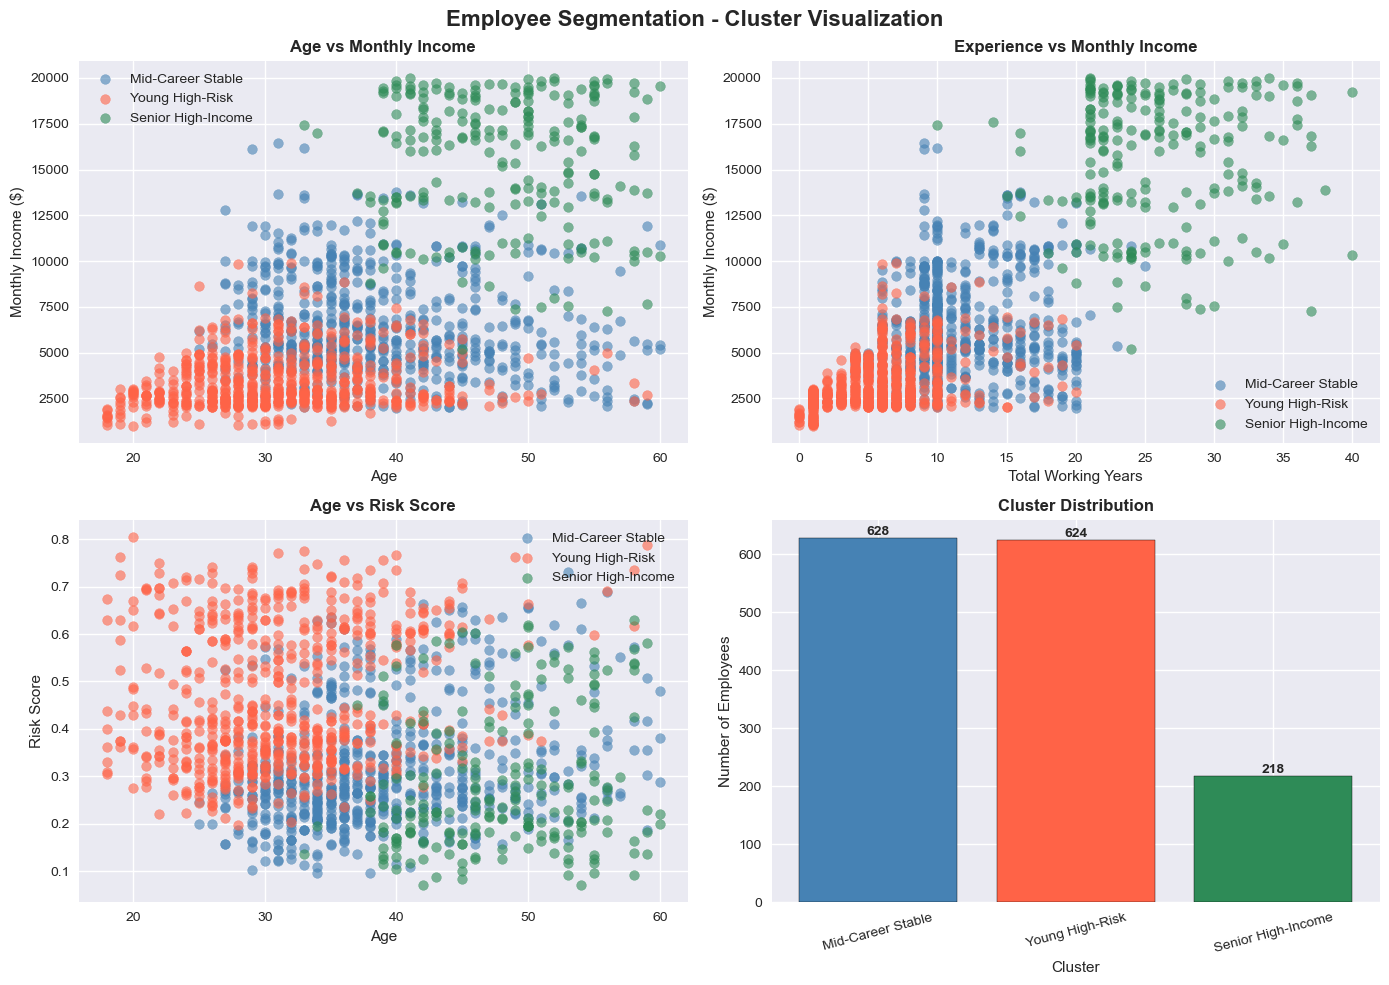

In [27]:
cluster_pdf = df_clustered.select(
    "cluster", "Age", "MonthlyIncome", "JobLevel",
    "TotalWorkingYears", "YearsAtCompany", "RiskScore"
).toPandas()

colors = {0: "steelblue", 1: "tomato", 2: "seagreen"}
labels = {0: "Mid-Career Stable", 1: "Young High-Risk", 2: "Senior High-Income"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age vs MonthlyIncome
for cluster in [0, 1, 2]:
    subset = cluster_pdf[cluster_pdf["cluster"] == cluster]
    axes[0, 0].scatter(subset["Age"], subset["MonthlyIncome"],
                       c=colors[cluster], label=labels[cluster], alpha=0.6)
axes[0, 0].set_title("Age vs Monthly Income", fontweight="bold")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Monthly Income ($)")
axes[0, 0].legend()

# 2. TotalWorkingYears vs MonthlyIncome
for cluster in [0, 1, 2]:
    subset = cluster_pdf[cluster_pdf["cluster"] == cluster]
    axes[0, 1].scatter(subset["TotalWorkingYears"], subset["MonthlyIncome"],
                       c=colors[cluster], label=labels[cluster], alpha=0.6)
axes[0, 1].set_title("Experience vs Monthly Income", fontweight="bold")
axes[0, 1].set_xlabel("Total Working Years")
axes[0, 1].set_ylabel("Monthly Income ($)")
axes[0, 1].legend()

# 3. Age vs RiskScore
for cluster in [0, 1, 2]:
    subset = cluster_pdf[cluster_pdf["cluster"] == cluster]
    axes[1, 0].scatter(subset["Age"], subset["RiskScore"],
                       c=colors[cluster], label=labels[cluster], alpha=0.6)
axes[1, 0].set_title("Age vs Risk Score", fontweight="bold")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Risk Score")
axes[1, 0].legend()

# 4. Cluster Distribution
cluster_counts = cluster_pdf["cluster"].value_counts().sort_index()
axes[1, 1].bar([labels[i] for i in cluster_counts.index],
               cluster_counts.values,
               color=[colors[i] for i in cluster_counts.index],
               edgecolor="black")
axes[1, 1].set_title("Cluster Distribution", fontweight="bold")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Number of Employees")
axes[1, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(cluster_counts.values):
    axes[1, 1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Employee Segmentation - Cluster Visualization",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\cluster_visualization.png", dpi=150)
plt.show()

### Cluster Visualization Insights

The scatter plots confirm the clear separation between the three employee segments:

**Age vs Monthly Income:**
- Senior High-Income employees (green) are clearly separated at the top
  with incomes between $5,210 and $19,999 and ages between 33 and 60
- Young High-Risk employees (red) are concentrated at the bottom
  with incomes between $1,009 and $9,907 and ages between 18 and 59
- Mid-Career Stable employees (blue) fall in the middle range
  with incomes between $2,001 and $16,422 and ages between 25 and 60

**Experience vs Monthly Income:**
- A clear positive correlation exists between experience and income
- Senior employees with 10 to 40 years of experience earn significantly more
- Young employees with 0 to 20 years cluster at lower income levels

**Age vs Risk Score:**
- Young High-Risk employees show the highest risk scores between 0.20 and 0.80
- Senior employees maintain lower risk scores between 0.07 and 0.63
- Mid-Career employees show moderate risk scores between 0.10 and 0.73

**Cluster Distribution:**
- Mid-Career Stable: 628 employees (42.7%)
- Young High-Risk: 624 employees (42.4%)
- Senior High-Income: 218 employees (14.8%)

### 7. Summary

In this notebook, we successfully completed the Employee Segmentation phase:

1. Selected 6 key features for clustering: Age, MonthlyIncome, JobLevel,
   TotalWorkingYears, YearsAtCompany, and RiskScore
2. Applied StandardScaler to normalize all features to the same scale
3. Used the Elbow Method to determine the optimal number of clusters
4. Selected K = 3 based on the highest Silhouette Score of 0.4052
5. Identified three distinct employee segments:
   - Cluster 0: Mid-Career Stable Employees (628 employees, 42.7%)
   - Cluster 1: Young High-Risk Employees (624 employees, 42.4%)
   - Cluster 2: Senior High-Income Employees (218 employees, 14.8%)

The clustering results will be used in the next phase to identify
high-risk employees and recommend targeted HR strategies.